# Mini Proyecto: ¿Cómo Aprende una Máquina?
### Visualizando el aprendizaje con datos sintéticos
#### Cloud, IA y Data Science — Ciclo 1

---

En proyectos anteriores hemos entrenado modelos sobre datasets reales. Funcionaban bien, pero había algo que no podíamos ver directamente: **¿qué ha aprendido el modelo exactamente?**

En este proyecto vamos a hacer algo diferente. En lugar de usar un dataset real, **vamos a generarlo nosotros mismos**. Eso nos da un control total sobre el problema: podemos decidir cuántas muestras hay, cuánto se mezclan las clases, cuánto ruido tiene... y sobre todo, como usaremos solo 2 variables, podremos **dibujar en pantalla la frontera que el modelo ha aprendido**.

Esa frontera, llamada **frontera de decisión**, es la respuesta visual a la pregunta "¿qué ha aprendido la máquina?". Es una de las herramientas más útiles para desarrollar intuición sobre cómo funcionan los algoritmos de clasificación.

El proyecto tiene estas fases:

1. **Generar datos sintéticos** — Creamos el problema desde cero
2. **Exploración visual** — Vemos el problema antes de que lo vea el modelo
3. **Entrenamiento y frontera de decisión** — Visualizamos lo que el modelo ha aprendido
4. **¿Qué pasa cuando el problema es más difícil?** — Exploramos el efecto del ruido y el solapamiento
5. **Dos modelos, dos fronteras** — Comparamos cómo aprenden distintos algoritmos
6. **Reflexión** — ¿Qué nos dice todo esto sobre el aprendizaje automático?

---
## Fase 1 — Generar datos sintéticos

### 1.1 Importar librerías

Además de las habituales, en este proyecto usamos dos funciones de `sklearn.datasets` que permiten **fabricar datasets artificiales** con las propiedades que nosotros decidamos:

- `make_classification`: genera un problema de clasificación con clases separables (o no)
- `make_moons`: genera dos clases en forma de medias lunas entrelazadas, un problema más difícil para ciertos modelos

También importamos dos modelos esta vez: **Regresión Logística** y **Árbol de Decisión**. Los compararemos al final.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


### 1.2 Crear el dataset sintético

`make_classification` genera un dataset de clasificación con los parámetros que nosotros le indiquemos. Es como un simulador de problemas de ML.

Los parámetros más importantes para este proyecto:

- `n_samples`: cuántos puntos generamos
- `n_features=2`: usamos **exactamente 2 variables** para poder dibujar el dataset en un plano 2D
- `n_informative=2`: las 2 variables son útiles para clasificar (sin variables irrelevantes)
- `n_redundant=0`: sin variables que sean combinaciones de otras
- `n_classes=2`: problema binario (clase 0 y clase 1)
- `class_sep`: separación entre las clases. A mayor valor, más fácil es el problema
- `random_state`: semilla aleatoria para reproducibilidad

Empezamos con un problema sencillo: clases bien separadas.

In [14]:
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    class_sep=1.5,      # Clases bien separadas
    random_state=42
)

print(f"Dataset generado: {X.shape[0]} muestras, {X.shape[1]} variables")
print(f"Clase 0: {(y == 0).sum()} muestras")
print(f"Clase 1: {(y == 1).sum()} muestras")

Dataset generado: 300 muestras, 2 variables
Clase 0: 150 muestras
Clase 1: 150 muestras


---
## Fase 2 — Exploración visual del problema

### 2.1 Ver el dataset antes de entrenar nada

Como tenemos exactamente 2 variables, podemos representar cada muestra como un punto en un plano: la variable 1 en el eje X, la variable 2 en el eje Y, y el color indica a qué clase pertenece.

Este gráfico nos muestra el problema tal como lo verá el modelo. Antes de entrenar, ya podemos hacernos una idea de si las clases son fácilmente separables o no.

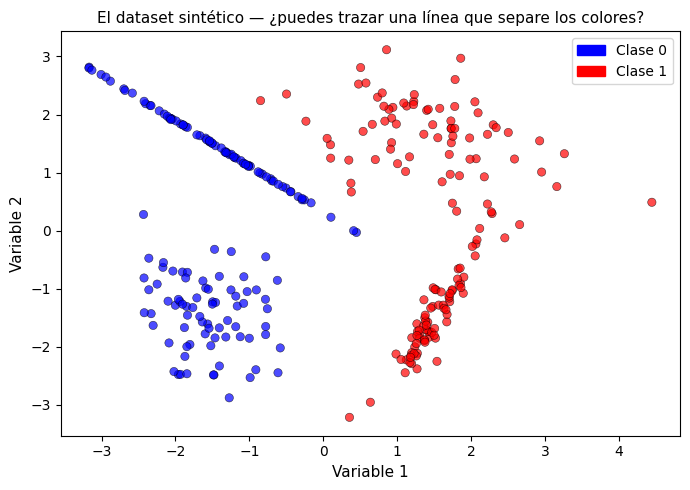

In [15]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    X[:, 0], X[:, 1],
    c=y, cmap='bwr', alpha=0.7, edgecolors='k', linewidths=0.4
)
plt.xlabel('Variable 1', fontsize=11)
plt.ylabel('Variable 2', fontsize=11)
plt.title('El dataset sintético — ¿puedes trazar una línea que separe los colores?', fontsize=11)
leyenda = [Patch(color='blue', label='Clase 0'), Patch(color='red', label='Clase 1')]
plt.legend(handles=leyenda)
plt.tight_layout()
plt.show()

> **Pregunta para la clase:** Mirando el gráfico, ¿podrías trazar tú mismo una línea (o curva) que separe los puntos azules de los rojos? Eso es exactamente lo que el modelo va a intentar aprender. La diferencia es que él lo hace de forma matemática y puede hacerlo con 10, 100 o 1.000 variables, donde nosotros ya no seríamos capaces de visualizarlo.

---
## Fase 3 — Entrenamiento y frontera de decisión

### 3.1 Preprocesar y entrenar

Seguimos el flujo estándar: dividir en train/test, escalar, y entrenar el modelo. El primer modelo que usamos es **Regresión Logística**.

A pesar de su nombre, la Regresión Logística es un clasificador, no un regresor. Aprende una **frontera lineal**: una línea recta (en 2D) o un hiperplano (en más dimensiones) que separa las clases. Es el modelo de clasificación más sencillo e interpretable que existe.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

modelo_lr = LogisticRegression(random_state=42)
modelo_lr.fit(X_train_s, y_train)

y_pred = modelo_lr.predict(X_test_s)
print(f"Exactitud en test: {accuracy_score(y_test, y_pred):.2%}")

Exactitud en test: 98.33%


### 3.2 Visualizar la frontera de decisión

Aquí está el núcleo de este proyecto. La **frontera de decisión** es la línea (o curva) que separa la zona donde el modelo predice Clase 0 de la zona donde predice Clase 1.

Para dibujarla, usamos un truco: generamos una rejilla densa de puntos que cubre todo el espacio visible, le pedimos al modelo que prediga la clase de cada uno de esos puntos, y coloreamos cada zona según la predicción. Así vemos exactamente cómo el modelo ha "dividido el espacio".

Los puntos reales del dataset se superponen encima para ver cuántos caen en la zona correcta.

In [17]:
def plot_frontera(modelo, X, y, scaler, titulo, ax):
    """
    Dibuja la frontera de decisión de un modelo sobre un dataset 2D.
    """
    # Generamos una rejilla que cubre el espacio de datos
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Escalamos y predecimos cada punto de la rejilla
    rejilla = np.c_[xx.ravel(), yy.ravel()]
    rejilla_s = scaler.transform(rejilla)
    Z = modelo.predict(rejilla_s).reshape(xx.shape)

    # Coloreamos las zonas de decisión
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='bwr')
    ax.contour(xx, yy, Z, colors='black', linewidths=1.2)

    # Superponemos los puntos reales
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr',
               edgecolors='k', linewidths=0.4, alpha=0.8)

    ax.set_xlabel('Variable 1')
    ax.set_ylabel('Variable 2')
    ax.set_title(titulo, fontsize=11)

print("✅ Función definida")

✅ Función definida


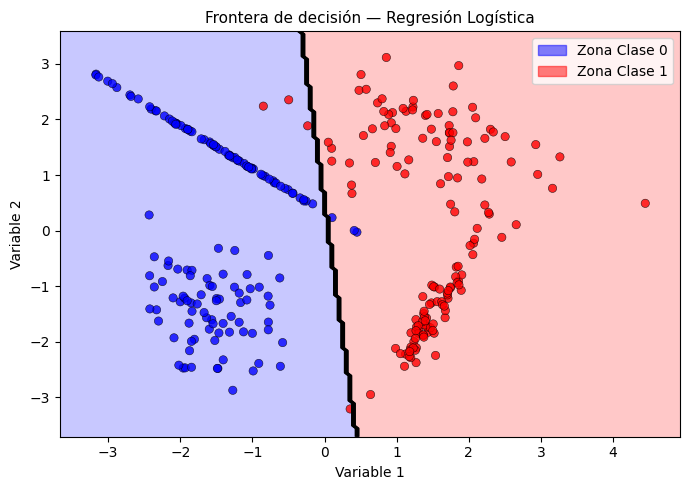

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_frontera(modelo_lr, X, y, scaler, 'Frontera de decisión — Regresión Logística', ax)
leyenda = [Patch(color='blue', alpha=0.5, label='Zona Clase 0'),
           Patch(color='red',  alpha=0.5, label='Zona Clase 1')]
ax.legend(handles=leyenda, loc='upper right')
plt.tight_layout()
plt.show()

> **Lo que estás viendo:** La línea negra es la frontera de decisión. Todo lo que queda a la izquierda (zona azul), el modelo lo clasificará como Clase 0. Todo lo que queda a la derecha (zona roja), como Clase 1. Los puntos mal clasificados son los que están en la zona del color contrario al suyo.
>
> Fíjate en que la frontera es una **línea recta**. Eso es una característica de la Regresión Logística: siempre aprende fronteras lineales. Si el problema real no es linealmente separable, este modelo tendrá un límite de rendimiento independientemente de cuántos datos tenga.

---
## Fase 4 — ¿Qué pasa cuando el problema es más difícil?

### 4.1 Efecto del solapamiento entre clases

Hasta ahora las clases estaban bien separadas (`class_sep=1.5`). Pero en la vida real los datos raramente son tan limpios. Vamos a generar el mismo tipo de dataset pero con distintos niveles de separación y ver cómo afecta al modelo.

El parámetro `class_sep` controla la distancia entre los centros de las clases. A menor valor, más se solapan los puntos de ambas clases y más difícil se vuelve el problema.

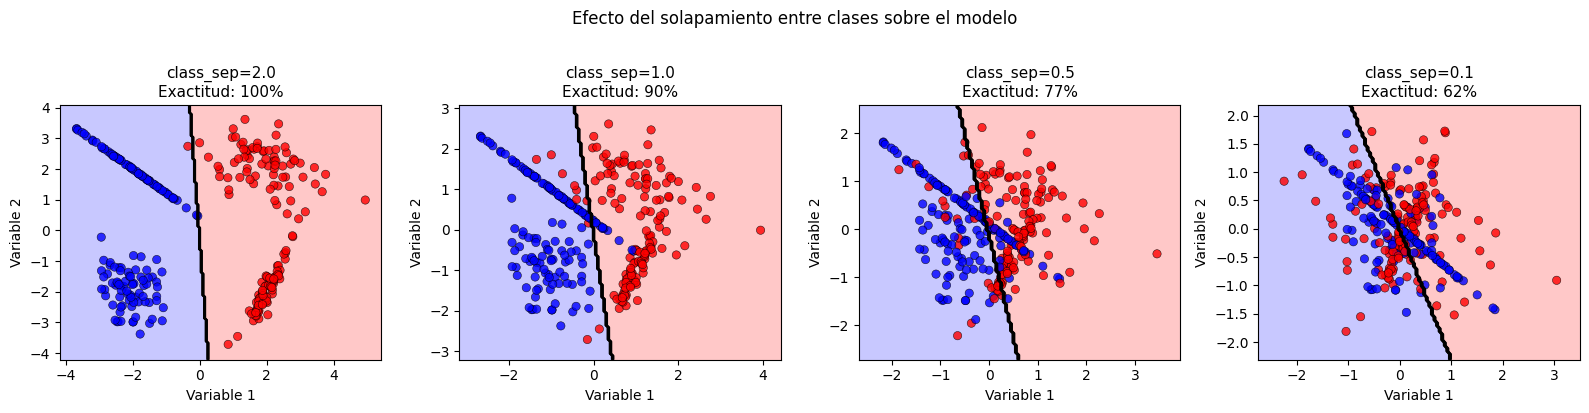

In [19]:
separaciones = [2.0, 1.0, 0.5, 0.1]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, sep in zip(axes, separaciones):
    X_s, y_s = make_classification(
        n_samples=300, n_features=2, n_informative=2,
        n_redundant=0, class_sep=sep, random_state=42
    )
    # Entrenamos un modelo rápido para cada caso
    sc = StandardScaler()
    Xs_t, Xs_v, ys_t, ys_v = train_test_split(X_s, y_s, test_size=0.2, random_state=42)
    Xs_t_s = sc.fit_transform(Xs_t)
    Xs_v_s = sc.transform(Xs_v)
    m = LogisticRegression(random_state=42)
    m.fit(Xs_t_s, ys_t)
    acc = accuracy_score(ys_v, m.predict(Xs_v_s))

    plot_frontera(m, X_s, y_s, sc, f'class_sep={sep}\nExactitud: {acc:.0%}', ax)

plt.suptitle('Efecto del solapamiento entre clases sobre el modelo', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

> **Conclusión clave:** A medida que las clases se solapan más, la exactitud baja inevitablemente. Esto no es un fallo del algoritmo: es una propiedad del problema. Si los datos de dos clases son intrínsecamente similares, ningún modelo del mundo podrá clasificarlos perfectamente. Saber cuándo un problema tiene un límite de rendimiento teórico es parte de la madurez como Data Scientist.

---
## Fase 5 — Dos modelos, dos fronteras

### 5.1 Un problema que la línea recta no puede resolver

Vamos a crear un dataset con una geometría especial: dos medias lunas entrelazadas. Visualmente, los puntos de cada clase forman una curva que se envuelve alrededor de la otra.

Este tipo de problema **no es linealmente separable**: ninguna línea recta puede separar correctamente las dos clases. Vamos a ver qué pasa cuando le pedimos a la Regresión Logística (que solo aprende líneas) que lo intente.

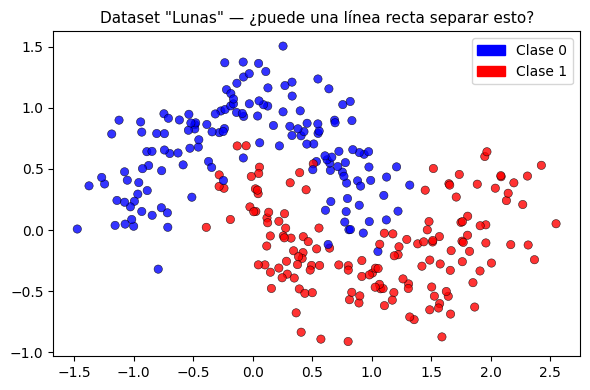

In [20]:
X_m, y_m = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X_m[:, 0], X_m[:, 1], c=y_m, cmap='bwr',
            edgecolors='k', linewidths=0.4, alpha=0.8)
leyenda = [Patch(color='blue', label='Clase 0'), Patch(color='red', label='Clase 1')]
plt.legend(handles=leyenda)
plt.title('Dataset "Lunas" — ¿puede una línea recta separar esto?', fontsize=11)
plt.tight_layout()
plt.show()

> **Pregunta para la clase:** ¿Podrías trazar una línea recta que separe perfectamente los puntos azules de los rojos? La respuesta es no. Pero sí podrías trazar una curva. Eso significa que necesitamos un modelo capaz de aprender fronteras no lineales.

### 5.2 Comparación: Regresión Logística vs Árbol de Decisión

Vamos a entrenar dos modelos sobre el dataset de lunas y comparar visualmente sus fronteras.

El **Árbol de Decisión** aprende reglas del tipo "si Variable 1 > 0.3 y Variable 2 < -0.5, entonces Clase 0". Como estas reglas se aplican de forma anidada, la frontera resultante no es una línea recta sino una serie de cortes horizontales y verticales que pueden aproximar formas más complejas.

Esta comparación nos permite ver algo fundamental: **el algoritmo determina la forma de la frontera**, independientemente de los datos.

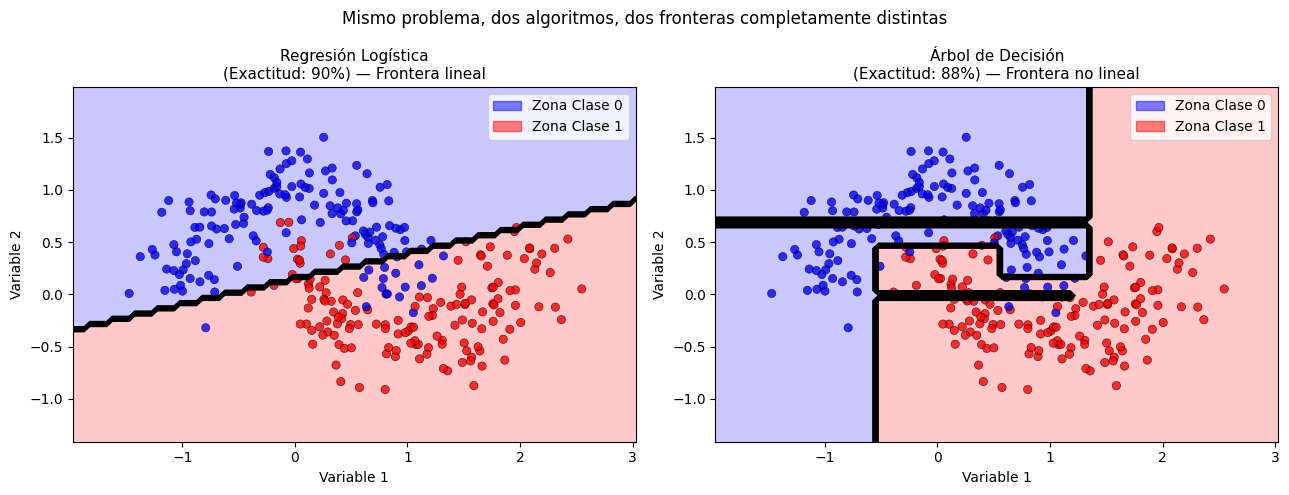

In [21]:
# Preparamos los datos de lunas
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)
sc_m = StandardScaler()
Xm_tr_s = sc_m.fit_transform(Xm_tr)
Xm_te_s = sc_m.transform(Xm_te)

# Entrenamos los dos modelos
lr  = LogisticRegression(random_state=42)
dt  = DecisionTreeClassifier(max_depth=5, random_state=42)

lr.fit(Xm_tr_s, ym_tr)
dt.fit(Xm_tr_s, ym_tr)

acc_lr = accuracy_score(ym_te, lr.predict(Xm_te_s))
acc_dt = accuracy_score(ym_te, dt.predict(Xm_te_s))

# Visualizamos las dos fronteras
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

plot_frontera(lr, X_m, y_m, sc_m,
    f'Regresión Logística\n(Exactitud: {acc_lr:.0%}) — Frontera lineal', axes[0])

plot_frontera(dt, X_m, y_m, sc_m,
    f'Árbol de Decisión\n(Exactitud: {acc_dt:.0%}) — Frontera no lineal', axes[1])

leyenda = [Patch(color='blue', alpha=0.5, label='Zona Clase 0'),
           Patch(color='red',  alpha=0.5, label='Zona Clase 1')]
for ax in axes:
    ax.legend(handles=leyenda, loc='upper right')

plt.suptitle('Mismo problema, dos algoritmos, dos fronteras completamente distintas',
             fontsize=12)
plt.tight_layout()
plt.show()

> **Lo que estás viendo:**
>
> - La Regresión Logística solo puede trazar una línea recta. En un problema con forma de luna, eso es claramente insuficiente y la exactitud lo refleja.
> - El Árbol de Decisión aproxima la forma curva con una serie de cortes rectangulares. Es más flexible y consigue mejor exactitud.
>
> **Pero cuidado:** El Árbol de Decisión también puede sobreajustarse (*overfitting*). Si le dejamos crecer sin límite (`max_depth`), memorizaría perfectamente el entrenamiento pero fallaría con datos nuevos. El parámetro `max_depth=5` es un control de complejidad.

### 5.3 Sobreajuste en acción: el árbol que memoriza

Vamos a ver visualmente qué ocurre cuando un Árbol de Decisión crece sin límite de profundidad. El modelo memorizará cada punto del entrenamiento, pero su frontera se volverá tan irregular que fallará con cualquier dato nuevo.

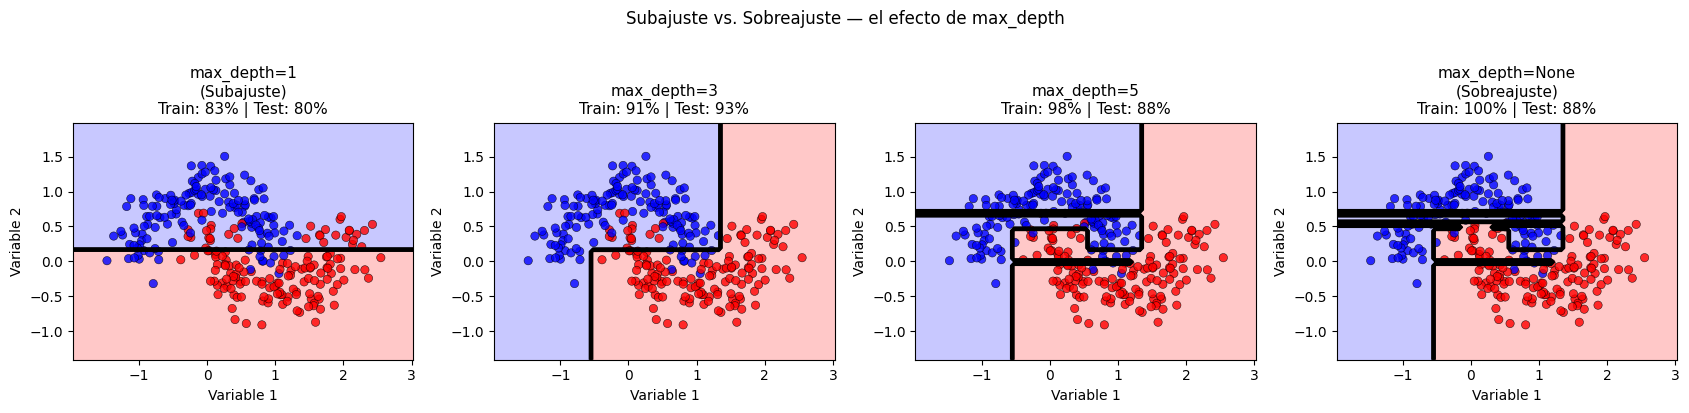

In [22]:
profundidades = [1, 3, 5, None]  # None = sin límite
etiquetas = ['max_depth=1\n(Subajuste)', 'max_depth=3', 'max_depth=5', 'max_depth=None\n(Sobreajuste)']

fig, axes = plt.subplots(1, 4, figsize=(17, 4))

for ax, depth, label in zip(axes, profundidades, etiquetas):
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(Xm_tr_s, ym_tr)
    acc_tr = accuracy_score(ym_tr, m.predict(Xm_tr_s))
    acc_te = accuracy_score(ym_te, m.predict(Xm_te_s))
    titulo = f'{label}\nTrain: {acc_tr:.0%} | Test: {acc_te:.0%}'
    plot_frontera(m, X_m, y_m, sc_m, titulo, ax)

plt.suptitle('Subajuste vs. Sobreajuste — el efecto de max_depth', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

> **La tensión central del ML visible en un gráfico:**
>
> - `max_depth=1`: el árbol es demasiado simple. No captura la forma del problema → **subajuste (underfitting)**. Exactitud baja tanto en train como en test.
> - `max_depth=None`: el árbol memorizó cada punto del entrenamiento. La frontera es caótica e irregular → **sobreajuste (overfitting)**. Exactitud perfecta en train, pero peor en test que con `max_depth=5`.
> - `max_depth=5`: el equilibrio. Lo suficientemente flexible para capturar la forma del problema, lo suficientemente simple para generalizar.
>
> Este equilibrio entre underfitting y overfitting es **el problema central del Machine Learning**. Todo el campo — regularización, validación cruzada, early stopping, dropout en redes neuronales — es en esencia formas distintas de encontrar ese punto óptimo.

---
## Fase 6 — Evaluación final y reflexión

### 6.1 Evaluación del mejor modelo sobre el dataset original

Volvemos al dataset de clasificación inicial (no el de lunas) y evaluamos los dos modelos con el informe completo para practicar la lectura de métricas en contexto.

In [23]:
# Reentrenamos sobre el dataset original (clases bien separadas)
lr_orig = LogisticRegression(random_state=42)
dt_orig = DecisionTreeClassifier(max_depth=5, random_state=42)

lr_orig.fit(X_train_s, y_train)
dt_orig.fit(X_train_s, y_train)

for nombre, modelo in [('Regresión Logística', lr_orig), ('Árbol de Decisión', dt_orig)]:
    pred = modelo.predict(X_test_s)
    print(f"=== {nombre} ===")
    print(classification_report(y_test, pred, target_names=['Clase 0', 'Clase 1']))
    print()

=== Regresión Logística ===
              precision    recall  f1-score   support

     Clase 0       0.97      1.00      0.98        30
     Clase 1       1.00      0.97      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60


=== Árbol de Decisión ===
              precision    recall  f1-score   support

     Clase 0       0.91      1.00      0.95        30
     Clase 1       1.00      0.90      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60




---
## Reflexión final

### ¿Qué hemos aprendido en este proyecto que no podríamos haber aprendido con un dataset real?

Al generar los datos nosotros mismos, hemos podido hacer algo imposible con datasets reales: **controlar exactamente la dificultad del problema** y observar cómo responde el modelo. Esto nos ha permitido ver:

- **La frontera de decisión** es la representación visual de lo que el modelo ha aprendido. Cada algoritmo aprende un tipo de frontera distinto.
- **El solapamiento entre clases** tiene un impacto directo e inevitable en la exactitud. Un modelo perfecto no siempre es posible.
- **El sobreajuste** no es un concepto abstracto: lo hemos visto en pantalla como una frontera irregular que memoriza el ruido en lugar de aprender el patrón.
- **No existe el mejor algoritmo universal.** La Regresión Logística es perfecta para problemas linealmente separables. El Árbol de Decisión es mejor cuando la frontera es curva. La elección del algoritmo depende del problema.

### Conceptos clave de esta sesión

| Concepto | Definición en una frase |
|---|---|
| Frontera de decisión | La línea (o curva) que separa las zonas donde el modelo predice cada clase |
| Underfitting | El modelo es demasiado simple para capturar el patrón real |
| Overfitting | El modelo memoriza el entrenamiento y falla con datos nuevos |
| Hiperparámetro | Un parámetro que nosotros controlamos (como `max_depth`) que determina la complejidad del modelo |
| Separabilidad lineal | Cuando las clases pueden separarse con una línea recta |

---

### Pregunta de reflexión final

> En el mundo real, nunca sabemos exactamente cómo están distribuidos los datos antes de recogerlos. ¿Qué herramientas de las que hemos visto hoy nos ayudan a entender si nuestro modelo está subajustando o sobreajustando, sin poder visualizar la frontera?

---
## Ejercicio propuesto (opcional / ampliación)

Experimenta con los parámetros de `make_classification` para crear tus propios problemas y observa cómo responde el modelo:

```python
X_exp, y_exp = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=3,       # ← Prueba con 3 clases
    class_sep=0.8,
    random_state=0
)
```

Preguntas guía:
1. ¿Cómo cambia la frontera de decisión cuando hay 3 clases en lugar de 2?
2. ¿Qué modelo funciona mejor con 3 clases: Regresión Logística o Árbol de Decisión?
3. Genera un dataset con `n_features=2` y `class_sep=0.0` (completamente solapado). ¿Cuál es la exactitud máxima que consigues con cualquier modelo? ¿Por qué?
4. **Reto visual:** Modifica la función `plot_frontera` para que también muestre un título con el número de puntos mal clasificados, no solo la exactitud.